In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

In [3]:
DATA_PATH = "../data/processed/processed_transactions.csv"

import pandas as pd

df = pd.read_csv(DATA_PATH)

df.head()

,transaction_id,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,...,abs_destination_balance_error,amount_to_oldbalanceOrg_ratio,amount_to_oldbalanceDest_ratio,is_zero_oldbalanceOrg,is_zero_oldbalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0,...,9839.64,0.057834,9839.640000,0,1,0,0,0,1,0
1,2,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0,...,1864.28,0.087731,1864.280000,0,1,0,0,0,1,0
2,3,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0,...,181.00,0.994505,181.000000,0,1,0,0,0,0,1
3,4,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0,...,21363.00,0.994505,0.008545,0,0,0,1,0,0,0
4,5,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0,...,11668.14,0.280788,11668.140000,0,1,0,0,0,1,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 28 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   transaction_id                  int64  
 1   step                            int64  
 2   type                            str    
 3   amount                          float64
 4   oldbalanceOrg                   float64
 5   newbalanceOrig                  float64
 6   oldbalanceDest                  float64
 7   newbalanceDest                  float64
 8   isFraud                         int64  
 9   isFlaggedFraud                  int64  
 10  is_origin_customer              int64  
 11  is_dest_customer                int64  
 12  is_dest_merchant                int64  
 13  origin_balance_diff             float64
 14  destination_balance_diff        float64
 15  origin_balance_error            float64
 16  destination_balance_error       float64
 17  abs_origin_balance_error        float6

In [5]:
df.describe()

,transaction_id,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,is_origin_customer,...,abs_destination_balance_error,amount_to_oldbalanceOrg_ratio,amount_to_oldbalanceDest_ratio,is_zero_oldbalanceOrg,is_zero_oldbalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6362620.0,...,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,3.181310e+06,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06,1.0,...,9.359907e+04,7.067448e+04,2.788383e+04,3.304376e-01,4.250431e-01,2.199226e-01,3.516633e-01,6.511783e-03,3.381461e-01,8.375622e-02
std,1.836730e+06,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03,0.0,...,4.350570e+05,5.084243e+05,1.879306e+05,4.703707e-01,4.943496e-01,4.141940e-01,4.774895e-01,8.043246e-02,4.730786e-01,2.770219e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.590656e+06,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.0,...,0.000000e+00,2.344011e-01,1.607037e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.181310e+06,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00,1.0,...,5.123620e+03,6.453832e+00,9.178313e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.771965e+06,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00,1.0,...,4.342133e+04,1.228776e+04,9.732300e+03,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,6.362620e+06,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00,1.0,...,7.588573e+07,9.244552e+07,6.096528e+07,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [6]:
df.isnull().sum()

transaction_id                    0
step                              0
type                              0
amount                            0
oldbalanceOrg                     0
newbalanceOrig                    0
oldbalanceDest                    0
newbalanceDest                    0
isFraud                           0
isFlaggedFraud                    0
is_origin_customer                0
is_dest_customer                  0
is_dest_merchant                  0
origin_balance_diff               0
destination_balance_diff          0
origin_balance_error              0
destination_balance_error         0
abs_origin_balance_error          0
abs_destination_balance_error     0
amount_to_oldbalanceOrg_ratio     0
amount_to_oldbalanceDest_ratio    0
is_zero_oldbalanceOrg             0
is_zero_oldbalanceDest            0
type_CASH_IN                      0
type_CASH_OUT                     0
type_DEBIT                        0
type_PAYMENT                      0
type_TRANSFER               

In [7]:
label_encoder = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = label_encoder.fit_transform(df[column])

df.head()

C:\Users\khushkant\AppData\Local\Temp\ipykernel_29948\1158129646.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include="object").columns:


,transaction_id,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,...,abs_destination_balance_error,amount_to_oldbalanceOrg_ratio,amount_to_oldbalanceDest_ratio,is_zero_oldbalanceOrg,is_zero_oldbalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,0,...,9839.64,0.057834,9839.640000,0,1,0,0,0,1,0
1,2,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,0,...,1864.28,0.087731,1864.280000,0,1,0,0,0,1,0
2,3,1,4,181.00,181.0,0.00,0.0,0.0,1,0,...,181.00,0.994505,181.000000,0,1,0,0,0,0,1
3,4,1,1,181.00,181.0,0.00,21182.0,0.0,1,0,...,21363.00,0.994505,0.008545,0,0,0,1,0,0,0
4,5,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,0,...,11668.14,0.280788,11668.140000,0,1,0,0,0,1,0


In [8]:
TARGET = "isFraud"

X = df.drop(columns=[TARGET])

y = df[TARGET]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (6362620, 27)
Target: (6362620,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5090096, 27)
(1272524, 27)


In [10]:
baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

c:\Users\khushkant\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline Logistic Regression

              precision    recall  f1-score   support

           0       1.00      0.91      0.95   1270881
           1       0.01      0.93      0.03      1643

    accuracy                           0.91   1272524
   macro avg       0.51      0.92      0.49   1272524
weighted avg       1.00      0.91      0.95   1272524



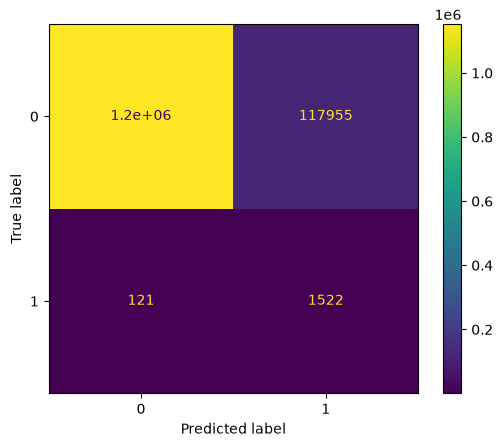

In [11]:
print("Baseline Logistic Regression")
print()

print(classification_report(y_test, baseline_predictions))

cm = confusion_matrix(y_test, baseline_predictions)

ConfusionMatrixDisplay(cm).plot()

plt.show()

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

Random Forest Results

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



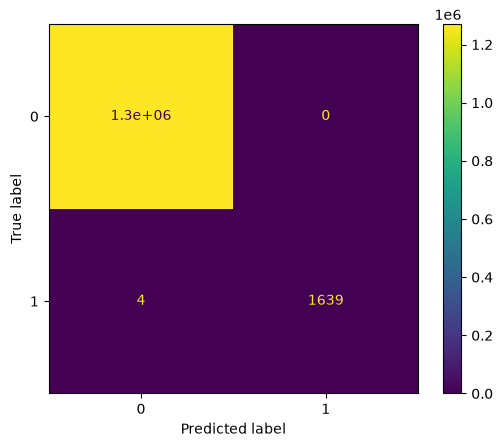

In [13]:
print("Random Forest Results")
print()

print(classification_report(y_test, rf_predictions))

cm = confusion_matrix(y_test, rf_predictions)

ConfusionMatrixDisplay(cm).plot()

plt.show()

In [14]:
precision = precision_score(y_test, rf_predictions)
recall = recall_score(y_test, rf_predictions)
f1 = f1_score(y_test, rf_predictions)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

Precision : 1.0
Recall    : 0.9975654290931223
F1 Score  : 0.9987812309567337


In [15]:
cm = confusion_matrix(y_test, rf_predictions)

false_negatives = cm[1][0]

print("False Negatives:", false_negatives)

False Negatives: 4


In [16]:
os.makedirs("models/saved_model", exist_ok=True)

joblib.dump(
    rf_model,
    "models/saved_model/fraud_detection_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
16,abs_origin_balance_error,0.168162
18,amount_to_oldbalanceOrg_ratio,0.164535
14,origin_balance_error,0.155028
12,origin_balance_diff,0.145667
5,newbalanceOrig,0.101525
4,oldbalanceOrg,0.042498
19,amount_to_oldbalanceDest_ratio,0.028245
2,type,0.026486
3,amount,0.025880
11,is_dest_merchant,0.022785


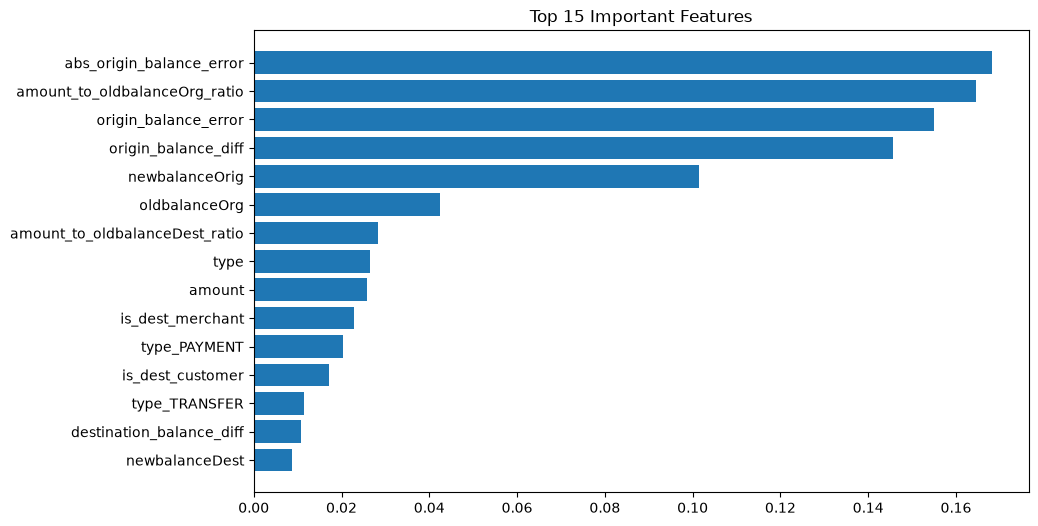

In [18]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()